In [44]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [45]:
#data batch size
BATCH_SIZE = 32
#diamensions of img
IMAGE_SIZE = (224, 224)

#get data to train from folder
train_data_dir = "/content/drive/MyDrive/data/dataset"

In [46]:
#split training data into training and validation
train_data = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                         batch_size=BATCH_SIZE,
                                                         image_size=IMAGE_SIZE,
                                                         subset="training",
                                                         validation_split=0.1,
                                                         seed=42)

Found 1080 files belonging to 7 classes.
Using 972 files for training.


In [47]:
validation_data = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                              batch_size=BATCH_SIZE,
                                                              image_size=IMAGE_SIZE,
                                                              subset="validation",
                                                              validation_split=0.1,
                                                              seed=42)

Found 1080 files belonging to 7 classes.
Using 108 files for validation.


In [48]:
#data feature scaling
train_data = train_data.map(lambda x,y:(x/255,y))
validation_data = validation_data.map(lambda x,y:(x/255,y))

In [49]:
#transfer learning(download pretrained model)
pretrained_model = tf.keras.applications.xception.Xception(include_top=False,
                                                           input_shape=(224,224,3),
                                                           weights='imagenet',
                                                           pooling='max')
# Unfreeze top layers
for layer in pretrained_model.layers[-50:]:
    layer.trainable = True

In [50]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])


In [51]:
#create model
model = tf.keras.models.Sequential()

model.add(data_augmentation)

model.add(pretrained_model)

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(units=128, activation='relu'))
model.add(tf.keras.layers.Dense(units=128, activation='relu'))
model.add(tf.keras.layers.Dense(units=32, activation='relu'))
model.add(tf.keras.layers.Dense(units=7, activation='softmax'))


In [52]:
#compile model
model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = ['accuracy'])

In [53]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 20,806,952 (79.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [57]:
history = model.fit(train_data,
                    epochs=10,
                    validation_data=validation_data)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 25s 817ms/step - accuracy: 0.5874 - loss: 1.1432 - val_accuracy: 0.4167 - val_loss: 3.0083
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 783ms/step - accuracy: 0.6121 - loss: 1.1232 - val_accuracy: 0.3796 - val_loss: 2.6251
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 23s 737ms/step - accuracy: 0.6008 - loss: 1.1229 - val_accuracy: 0.4537 - val_loss: 2.8363
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 23s 735ms/step - accuracy: 0.6008 - loss: 1.1376 - val_accuracy: 0.4352 - val_loss: 2.7241
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 23s 755ms/step - accuracy: 0.6595 - loss: 0.9584 - val_accuracy: 0.5370 - val_loss: 2.2626
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 766ms/step - accuracy: 0.6811 - loss: 0.8864 - val_accuracy: 0.5000 - val_loss: 1.7187
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 757ms/step - accuracy: 0.7037 - loss: 0.7953 - val_accuracy: 0.3611 - val_loss: 3.4799
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 23s 749ms/step - accuracy: 0.6986 - loss: 0.8338 - val_accu

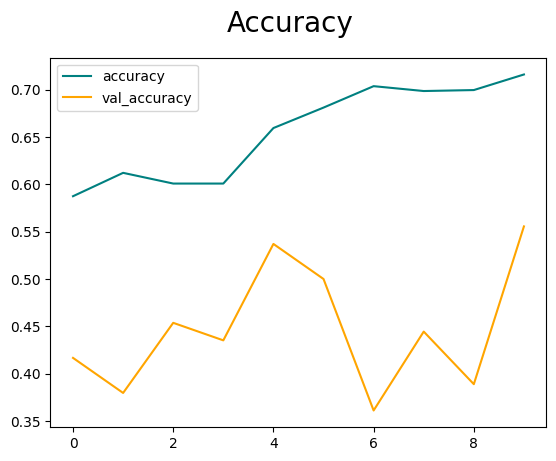

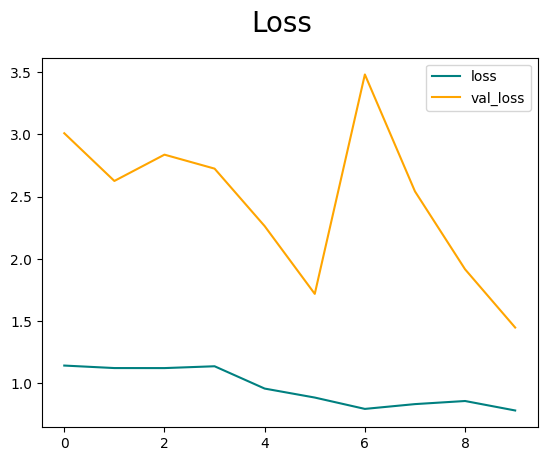

In [58]:
#plot acuuracy vs validation accuracy
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend()
plt.show()

#plot loss vs validation lass
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend()
plt.show()

In [59]:
model.save("my_model.keras")

In [64]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# New Section